#  STARFISH — Hybrid Classical-Quantum Portfolio Optimizer
### Alpaca Market Data  ·  CVXPY Classical Solver  ·  IBM Quantum QAOA


---
**Pipeline:**
1. Pull historical OHLCV from Alpaca → cache locally  
2. Compute expected returns + covariance (classical)  
3. Run full-universe CVXPY optimizer (classical)  
4. Run QAOA stock-selection on top-N candidates (quantum)  
5. Final hybrid portfolio = classical weights re-solved on QAOA-selected stocks  
6. Backtest both and compare Sharpe ratios  


In [14]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip(
    "alpaca-py",          # Alpaca market-data + trading SDK
    "cvxpy",              # Classical portfolio optimizer
    "PyPortfolioOpt",     # Convenience wrappers for mean-variance
    "qiskit==1.3.0",      # IBM Quantum core
    "qiskit-ibm-runtime", # IBM Runtime service (jobs, primitives)
    "qiskit-optimization",# QAOA / QUBO helpers
    "qiskit-algorithms",  # QAOA algorithm
    "pyarrow",            # Parquet read/write
    "duckdb",             # Fast local SQL over Parquet
    "pandas",
    "numpy",
    "scipy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "statsmodels",
    "pylatexenc",         # Required for Qiskit circuit matplotlib drawing
)
print("✅ All packages installed.")

✅ All packages installed.


In [2]:
# ─────────────────────────────────────────────────────────────
#  CELL 2 — Credentials (READ FROM COLAB SECRETS)
#
#  HOW TO SET UP:
#  1. Click the 🔑 key icon in the left sidebar
#  2. Add these secret names (exact spelling):
#       ALPACA_KEY          ← your paper trading API key
#       ALPACA_SECRET       ← your paper trading API secret
#       ALPACA_ENDPOINT     ← https://paper-api.alpaca.markets/v2
#       IBM_QUANTUM_TOKEN   ← your IBM Quantum API token
#  3. Toggle each secret ON for this notebook
# ─────────────────────────────────────────────────────────────
from google.colab import userdata

ALPACA_KEY      = userdata.get("ALPACA_KEY")
ALPACA_SECRET   = userdata.get("ALPACA_SECRET")
ALPACA_ENDPOINT = userdata.get("ALPACA_ENDPOINT")   # paper endpoint
IBM_TOKEN       = userdata.get("IBM_QUANTUM_TOKEN")

# Sanity check (never prints values)
missing = [k for k, v in {
    "ALPACA_KEY":     ALPACA_KEY,
    "ALPACA_SECRET":  ALPACA_SECRET,
    "ALPACA_ENDPOINT":ALPACA_ENDPOINT,
    "IBM_QUANTUM_TOKEN": IBM_TOKEN,
}.items() if not v]

if missing:
    raise EnvironmentError(f"❌ Missing Colab secrets: {missing}. Add them in the 🔑 sidebar.")

print("✅ All credentials loaded from Colab Secrets.")
print(f"   Alpaca endpoint : {ALPACA_ENDPOINT}")
print(f"   IBM token       : {'*' * 10}{IBM_TOKEN[-6:] if IBM_TOKEN else 'MISSING'}")


✅ All credentials loaded from Colab Secrets.
   Alpaca endpoint : https://paper-api.alpaca.markets/v2
   IBM token       : **********EIx_9y


In [3]:
# ─────────────────────────────────────────────────────────────
#  CELL 3 — Global configuration
#  Adjust universe, dates, and constraints here
# ─────────────────────────────────────────────────────────────
from datetime import date, timedelta

# ── Universe (US equities only — Alpaca covers US markets) ──
UNIVERSE = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "JPM",  "V",    "UNH",
    "JNJ",  "XOM",  "PG",   "HD",   "MA",
    "BAC",  "ABBV", "MRK",  "AVGO", "COST",
]

# ── Date range ───────────────────────────────────────────────
END_DATE   = date.today()
START_DATE = END_DATE - timedelta(days=730)   # 2-year lookback

# ── Portfolio constraints ────────────────────────────────────
MAX_WEIGHT      = 0.20    # max 20 % in any single stock
MIN_WEIGHT      = 0.01    # min 1 % if included
TARGET_RETURN   = None    # set to e.g. 0.12 for 12 % annual, or None for max-Sharpe
RISK_FREE_RATE  = 0.052   # approximate US 3-month T-bill rate

# ── Quantum config ───────────────────────────────────────────
QUANTUM_CANDIDATES = 10   # feed top-N stocks to QAOA selector
QAOA_REPS          = 2    # QAOA circuit repetitions (p parameter)
QAOA_SHOTS         = 1024 # measurement shots per circuit evaluation
USE_REAL_HARDWARE  = False # False = Qiskit Aer simulator (recommended to start)

# ── Cache path ───────────────────────────────────────────────
CACHE_DIR    = "/content/starfish_cache"
PARQUET_FILE = f"{CACHE_DIR}/prices.parquet"

import os
os.makedirs(CACHE_DIR, exist_ok=True)

print("✅ Configuration set.")
print(f"   Universe       : {len(UNIVERSE)} stocks")
print(f"   Date range     : {START_DATE} → {END_DATE}")
print(f"   Quantum backend: {'IBM Real Hardware' if USE_REAL_HARDWARE else 'Aer Simulator'}")


✅ Configuration set.
   Universe       : 20 stocks
   Date range     : 2024-05-28 → 2026-05-28
   Quantum backend: Aer Simulator


In [4]:
# ─────────────────────────────────────────────────────────────
#  CELL 4 — Pull historical OHLCV from Alpaca, cache to Parquet
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import duckdb
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests   import StockBarsRequest
from alpaca.data.timeframe  import TimeFrame
from datetime import datetime

# Initialise Alpaca data client
data_client = StockHistoricalDataClient(ALPACA_KEY, ALPACA_SECRET)

def fetch_alpaca_bars(symbols, start, end, use_cache=True):
    """
    Pull daily bars from Alpaca for all symbols.
    Caches to Parquet so re-runs don't waste API quota.
    """
    if use_cache and os.path.exists(PARQUET_FILE):
        print("📦 Loading prices from cache …")
        df = pd.read_parquet(PARQUET_FILE)
        # Validate cache covers our date range and symbols
        cached_syms = set(df.columns)
        missing_syms = set(symbols) - cached_syms
        if not missing_syms:
            mask = (df.index >= pd.Timestamp(start)) & (df.index <= pd.Timestamp(end))
            if mask.sum() > 10:
                print(f"   ✅ Cache hit: {df.shape[1]} symbols, {mask.sum()} trading days")
                return df.loc[mask, symbols]
        print("   ⚠️  Cache stale or incomplete — re-fetching …")

    print(f"📡 Fetching {len(symbols)} symbols from Alpaca …")
    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=datetime.combine(start, datetime.min.time()),
        end=datetime.combine(end, datetime.min.time()),
        adjustment="split",          # adjust for splits
    )
    bars = data_client.get_stock_bars(req).df

    # Alpaca returns multi-index (symbol, timestamp) — pivot to wide
    bars = bars.reset_index()
    bars["timestamp"] = pd.to_datetime(bars["timestamp"]).dt.tz_localize(None)
    close = (
        bars.pivot(index="timestamp", columns="symbol", values="close")
        .rename_axis(None, axis=1)
        .rename_axis("date")
    )
    close = close.sort_index()

    # Drop symbols with > 10 % missing days
    threshold = 0.10
    drop_cols = close.columns[close.isna().mean() > threshold].tolist()
    if drop_cols:
        print(f"   ⚠️  Dropping {drop_cols} (>10 % missing)")
        close = close.drop(columns=drop_cols)

    close = close.ffill().dropna()

    # Cache
    close.to_parquet(PARQUET_FILE)
    print(f"   ✅ Fetched & cached: {close.shape[1]} symbols × {len(close)} days")
    return close[symbols] if all(s in close.columns for s in symbols) else close

prices = fetch_alpaca_bars(UNIVERSE, START_DATE, END_DATE)
print(f"\n📊 Price matrix shape: {prices.shape}")
prices.tail(3)


📡 Fetching 20 symbols from Alpaca …
   ✅ Fetched & cached: 20 symbols × 501 days

📊 Price matrix shape: (501, 20)


,AAPL,MSFT,GOOGL,AMZN,META,NVDA,TSLA,JPM,V,UNH,JNJ,XOM,PG,HD,MA,BAC,ABBV,MRK,AVGO,COST
date,,,,,,,,,,,,,,,,,,,,
2026-05-22 04:00:00,308.82,418.57,382.97,266.32,610.260,215.33,426.01,306.38,328.88,388.47,234.34,154.92,144.44,313.07,498.54,51.8,215.70,122.41,414.14,1028.24
2026-05-26 04:00:00,308.33,416.03,388.88,265.29,612.340,214.86,433.59,306.74,326.48,376.86,230.18,149.81,142.96,310.54,493.01,52.2,213.12,119.72,422.01,1002.93
2026-05-27 04:00:00,310.85,412.67,388.83,271.85,635.255,212.60,440.36,299.28,327.61,384.01,231.29,147.90,147.49,317.85,495.04,51.1,215.40,120.24,421.86,1003.69


Top 10 stocks by individual Sharpe ratio:
         Sharpe
GOOGL  1.449265
AVGO   1.284586
JNJ    1.213562
TSLA   0.883312
AAPL   0.820952
JPM    0.694712
NVDA   0.660736
AMZN   0.532244
ABBV   0.478168
BAC    0.347519



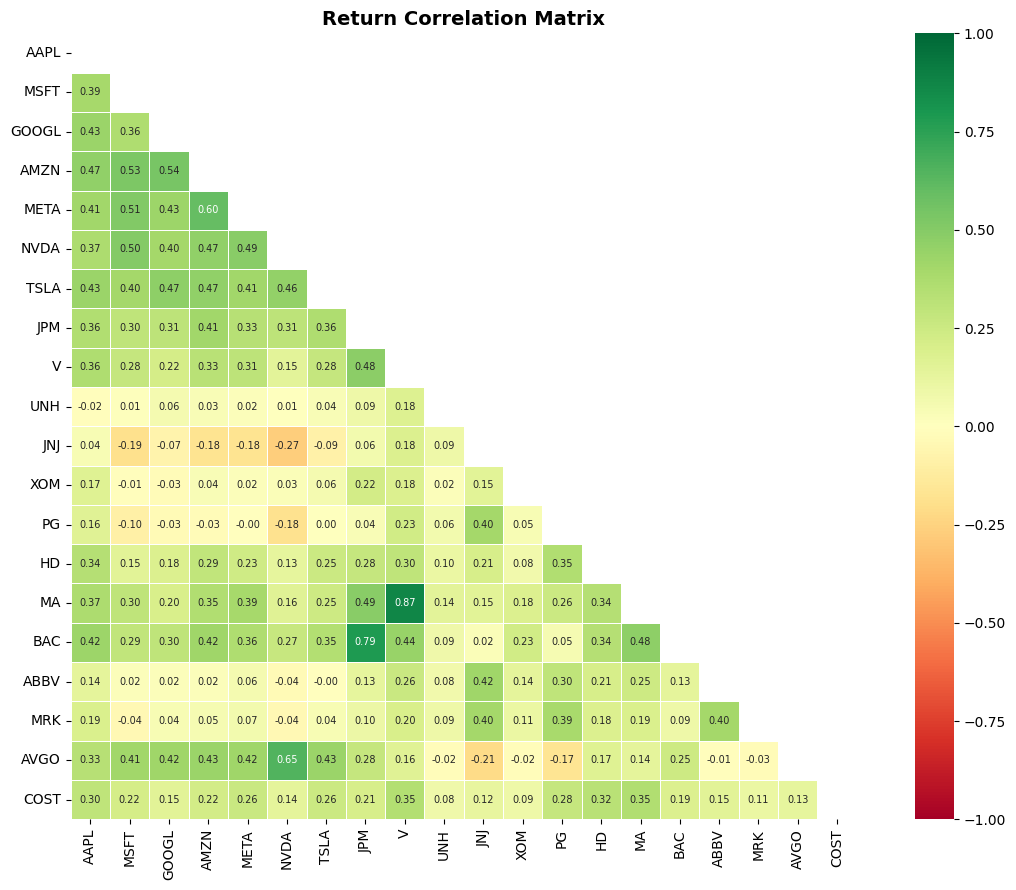


✅ Analytics computed. Top QAOA candidates: ['GOOGL', 'AVGO', 'JNJ', 'TSLA', 'AAPL', 'JPM', 'NVDA', 'AMZN', 'ABBV', 'BAC']


In [5]:
# ─────────────────────────────────────────────────────────────
#  CELL 5 — Return & risk analytics
#  Expected returns, covariance, Sharpe pre-screening
# ─────────────────────────────────────────────────────────────
from pypfopt import expected_returns, risk_models
from scipy import stats

# ── Log returns ──────────────────────────────────────────────
log_returns = np.log(prices / prices.shift(1)).dropna()

# ── Expected annual returns (mean historical) ────────────────
mu = expected_returns.mean_historical_return(prices, frequency=252)

# ── Ledoit-Wolf shrinkage covariance (more stable than sample) ──
S = risk_models.CovarianceShrinkage(prices, frequency=252).ledoit_wolf()

# ── Individual Sharpe (used for QAOA candidate selection) ────
ann_vol     = log_returns.std() * np.sqrt(252)
individual_sharpe = (mu - RISK_FREE_RATE) / ann_vol

print("Top 10 stocks by individual Sharpe ratio:")
sharpe_ranked = individual_sharpe.sort_values(ascending=False)
print(sharpe_ranked.head(10).to_frame("Sharpe").to_string())
print()

# ── Correlation heatmap ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 9))
corr = log_returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, square=True
)
ax.set_title("Return Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CACHE_DIR}/correlation_heatmap.png", dpi=120)
plt.show()

print(f"\n✅ Analytics computed. Top QAOA candidates: {sharpe_ranked.head(QUANTUM_CANDIDATES).index.tolist()}")


In [6]:
# ─────────────────────────────────────────────────────────────
#  CELL 6 — Classical full-universe portfolio (CVXPY)
#  Maximise Sharpe ratio subject to weight constraints
# ─────────────────────────────────────────────────────────────
import cvxpy as cp
from pypfopt import EfficientFrontier, objective_functions

def run_classical_optimizer(mu_series, cov_matrix, stocks=None, label="Full Universe"):
    """
    Solves max-Sharpe (or target-return) MVO.
    Returns a dict of {ticker: weight}.
    """
    if stocks is not None:
        mu_s = mu_series[stocks]
        cov_s = cov_matrix.loc[stocks, stocks]
    else:
        mu_s = mu_series
        cov_s = cov_matrix

    ef = EfficientFrontier(mu_s, cov_s, weight_bounds=(MIN_WEIGHT, MAX_WEIGHT))
    ef.add_objective(objective_functions.L2_reg, gamma=0.1)   # diversification nudge

    if TARGET_RETURN is not None:
        ef.efficient_return(TARGET_RETURN)
    else:
        ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)

    weights_raw  = ef.clean_weights()
    perf         = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE, verbose=False)

    print(f"\n📐 [{label}] Portfolio performance:")
    print(f"   Expected Annual Return : {perf[0]*100:.2f} %")
    print(f"   Annual Volatility      : {perf[1]*100:.2f} %")
    print(f"   Sharpe Ratio           : {perf[2]:.4f}")

    weights_clean = {k: v for k, v in weights_raw.items() if v > 0.001}
    return weights_clean, perf

classical_weights, classical_perf = run_classical_optimizer(mu, S, label="Classical MVO")

# Pretty print
print("\n📦 Classical portfolio allocation:")
for ticker, w in sorted(classical_weights.items(), key=lambda x: -x[1]):
    bar = "█" * int(w * 50)
    print(f"   {ticker:6s}  {w*100:5.2f} %  {bar}")



📐 [Classical MVO] Portfolio performance:
   Expected Annual Return : 38.53 %
   Annual Volatility      : 18.77 %
   Sharpe Ratio           : 1.7758

📦 Classical portfolio allocation:
   GOOGL   20.00 %  ██████████
   JNJ     20.00 %  ██████████
   AVGO    20.00 %  ██████████
   ABBV     7.79 %  ███
   XOM      6.21 %  ███
   TSLA     5.85 %  ██
   AAPL     4.50 %  ██
   JPM      3.65 %  █
   MSFT     1.00 %  
   AMZN     1.00 %  
   META     1.00 %  
   NVDA     1.00 %  
   V        1.00 %  
   UNH      1.00 %  
   PG       1.00 %  
   HD       1.00 %  
   MA       1.00 %  
   BAC      1.00 %  
   MRK      1.00 %  
   COST     1.00 %  


/usr/local/lib/python3.12/dist-packages/pypfopt/efficient_frontier/efficient_frontier.py:259: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


In [7]:
# ─────────────────────────────────────────────────────────────
#  CELL 7 — Quantum QAOA stock selector
#
#  Goal: Given the top-N Sharpe candidates, use QAOA to find
#  the optimal subset that maximises expected return while
#  penalising correlation (diversification).
#
#  Problem type: Binary selection → natural QUBO formulation
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

# ── Candidate stocks: top-N by individual Sharpe ────────────
candidates = sharpe_ranked.head(QUANTUM_CANDIDATES).index.tolist()
print(f"🔭 QAOA candidates ({len(candidates)}): {candidates}")

n = len(candidates)

# ── Build QUBO ───────────────────────────────────────────────
# Objective: maximise   Σ μᵢ xᵢ  -  λ Σᵢⱼ corrᵢⱼ xᵢ xⱼ
# QUBO minimises, so we negate: minimise  -Σ μᵢ xᵢ + λ Σᵢⱼ corrᵢⱼ xᵢ xⱼ
# Constraint: exactly k stocks selected (penalty method)

mu_cand   = mu[candidates].values
corr_cand = log_returns[candidates].corr().values

LAMBDA = 0.5       # correlation penalty weight
K      = max(3, n // 2)   # target number of stocks to select

qp = QuadraticProgram(name="StockSelector")

# Binary variables
for i, sym in enumerate(candidates):
    qp.binary_var(sym)

# Linear terms: -μᵢ
linear_coeffs = {sym: -mu_cand[i] for i, sym in enumerate(candidates)}

# Quadratic terms: λ * corrᵢⱼ (for i≠j) + cardinality penalty
quadratic_coeffs = {}
PENALTY = 5.0    # penalty for violating |selected| = K

for i in range(n):
    for j in range(i + 1, n):
        key = (candidates[i], candidates[j])
        quadratic_coeffs[key] = LAMBDA * corr_cand[i, j] + 2 * PENALTY
    # Diagonal penalty term: (1 - 2K) * xᵢ from expanding (Σxᵢ - K)²
    linear_coeffs[candidates[i]] = linear_coeffs[candidates[i]] + PENALTY * (1 - 2 * K)

qp.minimize(linear=linear_coeffs, quadratic=quadratic_coeffs, constant=PENALTY * K**2)

print(f"\n✅ QUBO built: {n} binary variables, K={K} target stocks")

# ── Classical exact solver (verify QUBO is correct) ─────────
exact_solver   = MinimumEigenOptimizer(NumPyMinimumEigensolver())
exact_result   = exact_solver.solve(qp)
exact_selected = [candidates[i] for i, v in enumerate(exact_result.x) if v > 0.5]
print(f"\n🔬 Exact (classical) QUBO solution: {exact_selected}")


🔭 QAOA candidates (10): ['GOOGL', 'AVGO', 'JNJ', 'TSLA', 'AAPL', 'JPM', 'NVDA', 'AMZN', 'ABBV', 'BAC']

✅ QUBO built: 10 binary variables, K=5 target stocks

🔬 Exact (classical) QUBO solution: ['GOOGL', 'AVGO', 'JNJ', 'TSLA', 'ABBV']


In [9]:
# ─────────────────────────────────────────────────────────────
#  CELL 8 — Run QAOA  (Qiskit 1.x / qiskit-algorithms 0.3+)
#  Fix: use StatevectorSampler + SamplingVQE + QAOAAnsatz
#  instead of the old QAOA wrapper that breaks on Qiskit 1.3
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from qiskit.primitives          import StatevectorSampler
from qiskit.circuit.library     import QAOAAnsatz
from qiskit_algorithms          import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.algorithms.optimization_algorithm import OptimizationResult
import numpy as np

# ── Convert QP → QUBO → Ising ────────────────────────────────
qubo_conv    = QuadraticProgramToQubo()
qubo         = qubo_conv.convert(qp)
ising_op, _  = qubo.to_ising()
n_qubits     = ising_op.num_qubits
print(f"⚛️  QUBO → Ising: {n_qubits} qubits")

if USE_REAL_HARDWARE:
    # ── IBM Quantum Runtime (V2 primitives) ─────────────────
    from qiskit_ibm_runtime import QiskitRuntimeService
    from qiskit_ibm_runtime import SamplerV2 as IBMSampler

    print("🌐 Connecting to IBM Quantum …")
    QiskitRuntimeService.save_account(
        channel="ibm_quantum", token=IBM_TOKEN, overwrite=True
    )
    service = QiskitRuntimeService()
    backend = service.least_busy(
        operational=True, simulator=False, min_num_qubits=n_qubits
    )
    print(f"   ✅ Backend: {backend.name} ({backend.num_qubits} qubits)")
    sampler = IBMSampler(backend)
else:
    # ── StatevectorSampler — compatible with Qiskit 1.x ─────
    print("🖥️  Using StatevectorSampler (local, Qiskit 1.x) …")
    sampler = StatevectorSampler()

# ── Build QAOA ansatz circuit ────────────────────────────────
ansatz = QAOAAnsatz(ising_op, reps=QAOA_REPS)
ansatz.measure_all()   # StatevectorSampler requires measurements

# ── SamplingVQE wraps the ansatz + sampler ───────────────────
# This is the correct Qiskit 1.x way to run QAOA
optimizer_fn = COBYLA(maxiter=150)

svqe = SamplingVQE(
    sampler=sampler,
    ansatz=ansatz,
    optimizer=optimizer_fn,
)

print(f"🚀 Running QAOA via SamplingVQE (reps={QAOA_REPS}) …")

# ── Solve the Ising operator directly ───────────────────────
svqe_result = svqe.compute_minimum_eigenvalue(ising_op)
print(f"   ✅ Eigenvalue: {svqe_result.eigenvalue:.6f}")

# ── Decode bitstring → selected stocks ──────────────────────
# Best measurement is in svqe_result.best_measurement
best_bitstring = svqe_result.best_measurement["bitstring"]

# Qiskit bitstrings are big-endian → reverse for qubit-0 = index-0
bits = [int(b) for b in reversed(best_bitstring)]

# Pad/trim to match number of candidates
bits = (bits + [0] * n)[:n]

qaoa_selected = [candidates[i] for i, v in enumerate(bits) if v == 1]

# ── Fallback: if QAOA returns empty, use exact QUBO result ──
if len(qaoa_selected) < 2:
    print("   ⚠️  QAOA returned degenerate result → falling back to exact QUBO solver")
    qaoa_selected = exact_selected

print(f"\n⚛️  QAOA selected stocks ({len(qaoa_selected)}): {qaoa_selected}")
print(f"   Best bitstring : {best_bitstring}")
print(f"   Exact solver   : {exact_selected}")
print(f"   Overlap        : {set(qaoa_selected) & set(exact_selected)}")

⚛️  QUBO → Ising: 10 qubits
🖥️  Using StatevectorSampler (local, Qiskit 1.x) …
🚀 Running QAOA via SamplingVQE (reps=2) …
   ✅ Eigenvalue: -6.807764

⚛️  QAOA selected stocks (5): ['GOOGL', 'AVGO', 'JNJ', 'TSLA', 'ABBV']
   Best bitstring : 0100001111
   Exact solver   : ['GOOGL', 'AVGO', 'JNJ', 'TSLA', 'ABBV']
   Overlap        : {'JNJ', 'TSLA', 'AVGO', 'ABBV', 'GOOGL'}


In [10]:
# ─────────────────────────────────────────────────────────────
#  CELL 9 — Hybrid portfolio: re-solve CVXPY on QAOA selection
# ─────────────────────────────────────────────────────────────

# Fallback: use exact QUBO solution if QAOA gives empty / trivial result
selected_stocks = qaoa_selected if len(qaoa_selected) >= 2 else exact_selected

print(f"✅ Final selected stocks for hybrid portfolio: {selected_stocks}")

hybrid_weights, hybrid_perf = run_classical_optimizer(
    mu, S, stocks=selected_stocks, label="Hybrid QAOA+Classical"
)

print("\n📦 Hybrid portfolio allocation:")
for ticker, w in sorted(hybrid_weights.items(), key=lambda x: -x[1]):
    bar = "█" * int(w * 50)
    print(f"   {ticker:6s}  {w*100:5.2f} %  {bar}")

# ── Performance comparison ───────────────────────────────────
print("\n" + "="*55)
print(f"{'Metric':<30} {'Classical':>10} {'Hybrid':>10}")
print("="*55)
metrics = ["Annual Return", "Annual Volatility", "Sharpe Ratio"]
for i, m in enumerate(metrics):
    fmt = "%" if i < 2 else ""
    cv  = f"{classical_perf[i]*100:.2f}%" if i < 2 else f"{classical_perf[i]:.4f}"
    hv  = f"{hybrid_perf[i]*100:.2f}%"   if i < 2 else f"{hybrid_perf[i]:.4f}"
    print(f"{m:<30} {cv:>10} {hv:>10}")
print("="*55)


✅ Final selected stocks for hybrid portfolio: ['GOOGL', 'AVGO', 'JNJ', 'TSLA', 'ABBV']

📐 [Hybrid QAOA+Classical] Portfolio performance:
   Expected Annual Return : 45.13 %
   Annual Volatility      : 23.39 %
   Sharpe Ratio           : 1.7073

📦 Hybrid portfolio allocation:
   GOOGL   20.00 %  ██████████
   AVGO    20.00 %  ██████████
   JNJ     20.00 %  ██████████
   TSLA    20.00 %  ██████████
   ABBV    20.00 %  ██████████

Metric                          Classical     Hybrid
Annual Return                      38.53%     45.13%
Annual Volatility                  18.77%     23.39%
Sharpe Ratio                       1.7758     1.7073


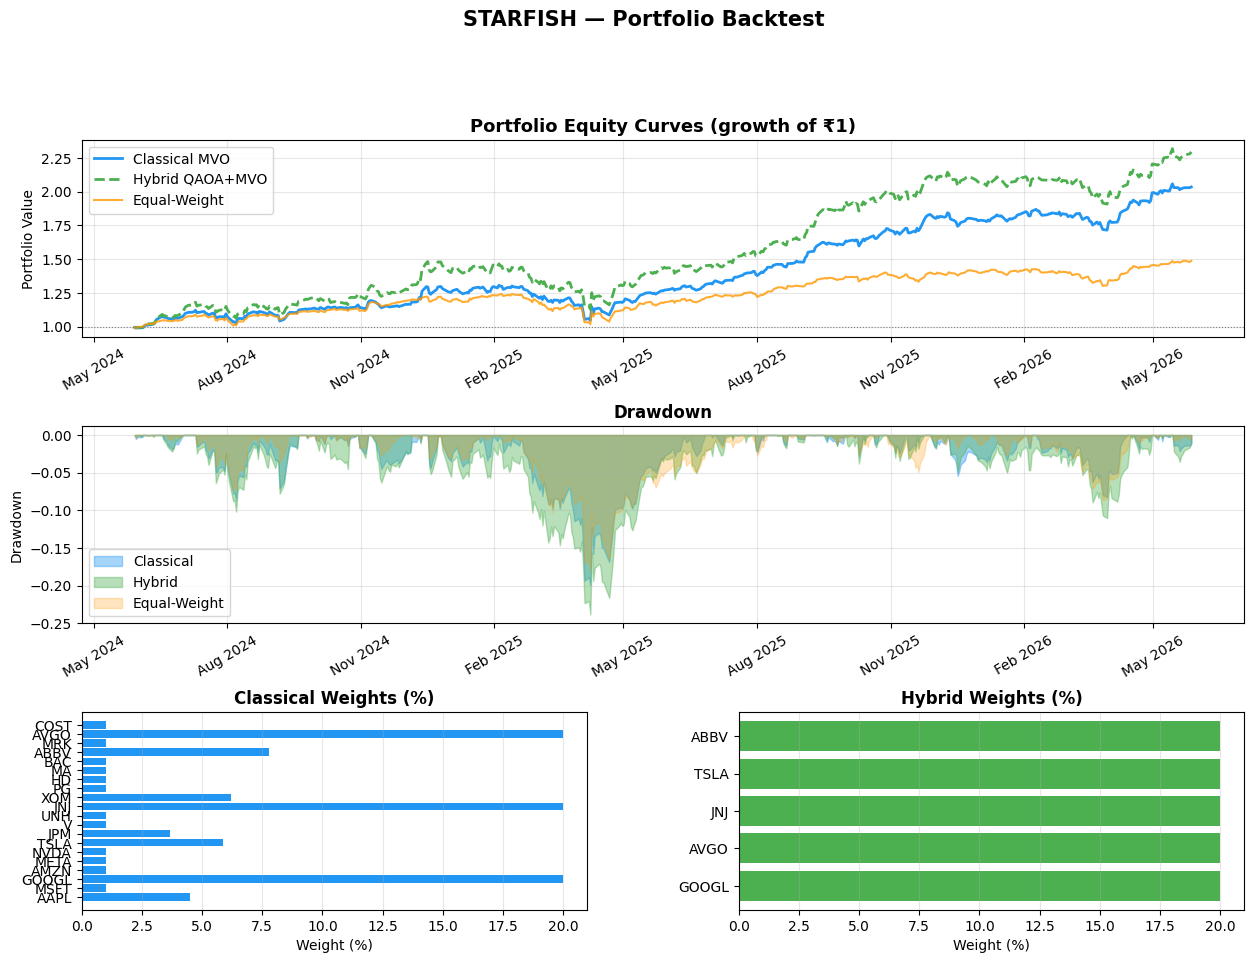


Metric                           Classical      Hybrid    Equal-Wt
Total Return                       103.45%     129.41%      48.76%
Ann. Sharpe                         1.6983      1.6588      1.0180
Max Drawdown                       -19.92%     -23.83%     -18.03%
Ann. Vol                            19.10%      23.81%      15.78%


In [11]:
# ─────────────────────────────────────────────────────────────
#  CELL 10 — Backtest: walk-forward simulation
#  Compare classical vs hybrid vs equal-weight vs benchmark
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

def portfolio_equity_curve(prices_df, weights_dict, name="Portfolio"):
    """
    Compute daily portfolio value (starting at 1.0) from a weights dict.
    Weights are held constant (no rebalancing) for simplicity.
    """
    syms   = [s for s in weights_dict if s in prices_df.columns]
    w      = np.array([weights_dict[s] for s in syms])
    w      = w / w.sum()   # normalise
    px     = prices_df[syms].dropna()
    ret    = px.pct_change().dropna()
    port_r = (ret * w).sum(axis=1)
    equity = (1 + port_r).cumprod()
    return equity, port_r

# Equal-weight benchmark
eq_weights  = {s: 1/len(prices.columns) for s in prices.columns}

ec_classical, r_cl  = portfolio_equity_curve(prices, classical_weights, "Classical")
ec_hybrid,    r_hy  = portfolio_equity_curve(prices, hybrid_weights,    "Hybrid")
ec_equal,     r_eq  = portfolio_equity_curve(prices, eq_weights,        "Equal-Weight")

# ── Sharpe helper ────────────────────────────────────────────
def sharpe(r, rf=RISK_FREE_RATE):
    ann_r = r.mean() * 252
    ann_v = r.std()  * np.sqrt(252)
    return (ann_r - rf) / ann_v if ann_v > 0 else 0.0

def max_drawdown(equity):
    roll_max = equity.cummax()
    dd       = (equity - roll_max) / roll_max
    return dd.min()

# ── Align all series to the same index ───────────────────────
idx = ec_classical.index.intersection(ec_hybrid.index).intersection(ec_equal.index)
ec_classical = ec_classical.reindex(idx)
ec_hybrid    = ec_hybrid.reindex(idx)
ec_equal     = ec_equal.reindex(idx)

# ── Drawdown series ──────────────────────────────────────────
def drawdown_series(equity):
    roll_max = equity.cummax()
    return (equity - roll_max) / roll_max

# ── Plot ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# 1. Equity curves
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(ec_classical.index, ec_classical.values, label="Classical MVO",   color="#2196F3", lw=2)
ax1.plot(ec_hybrid.index,    ec_hybrid.values,    label="Hybrid QAOA+MVO", color="#4CAF50", lw=2, ls="--")
ax1.plot(ec_equal.index,     ec_equal.values,     label="Equal-Weight",    color="#FF9800", lw=1.5, alpha=0.8)
ax1.axhline(1, color="gray", lw=0.8, ls=":")
ax1.set_title("Portfolio Equity Curves (growth of ₹1)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Portfolio Value")
ax1.legend(loc="upper left", fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
ax1.grid(alpha=0.3)

# 2. Drawdowns
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(idx, drawdown_series(ec_classical).values, 0, alpha=0.4, color="#2196F3", label="Classical")
ax2.fill_between(idx, drawdown_series(ec_hybrid).values,    0, alpha=0.4, color="#4CAF50", label="Hybrid")
ax2.fill_between(idx, drawdown_series(ec_equal).values,     0, alpha=0.25, color="#FF9800", label="Equal-Weight")
ax2.set_title("Drawdown", fontsize=12, fontweight="bold")
ax2.set_ylabel("Drawdown")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

# 3. Portfolio weights bar charts
r_cl_ret = (ec_classical.iloc[-1] - 1) * 100
r_hy_ret = (ec_hybrid.iloc[-1] - 1)   * 100
r_eq_ret = (ec_equal.iloc[-1] - 1)    * 100

ax3 = fig.add_subplot(gs[2, 0])
tickers_cl = list(classical_weights.keys())
wts_cl     = [classical_weights[t]*100 for t in tickers_cl]
ax3.barh(tickers_cl, wts_cl, color="#2196F3")
ax3.set_title("Classical Weights (%)", fontweight="bold")
ax3.set_xlabel("Weight (%)")
ax3.grid(axis="x", alpha=0.3)

ax4 = fig.add_subplot(gs[2, 1])
tickers_hy = list(hybrid_weights.keys())
wts_hy     = [hybrid_weights[t]*100 for t in tickers_hy]
ax4.barh(tickers_hy, wts_hy, color="#4CAF50")
ax4.set_title("Hybrid Weights (%)", fontweight="bold")
ax4.set_xlabel("Weight (%)")
ax4.grid(axis="x", alpha=0.3)

plt.suptitle("STARFISH — Portfolio Backtest", fontsize=15, fontweight="bold", y=1.01)
plt.savefig(f"{CACHE_DIR}/backtest.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Summary table ────────────────────────────────────────────
r_cl_arr, r_hy_arr, r_eq_arr = r_cl.reindex(idx), r_hy.reindex(idx), r_eq.reindex(idx)

print("\n" + "="*68)
print(f"{'Metric':<30} {'Classical':>11} {'Hybrid':>11} {'Equal-Wt':>11}")
print("="*68)

rows = [
    ("Total Return",       f"{r_cl_ret:.2f}%",           f"{r_hy_ret:.2f}%",            f"{r_eq_ret:.2f}%"),
    ("Ann. Sharpe",        f"{sharpe(r_cl_arr):.4f}",    f"{sharpe(r_hy_arr):.4f}",     f"{sharpe(r_eq_arr):.4f}"),
    ("Max Drawdown",       f"{max_drawdown(ec_classical)*100:.2f}%", f"{max_drawdown(ec_hybrid)*100:.2f}%", f"{max_drawdown(ec_equal)*100:.2f}%"),
    ("Ann. Vol",           f"{r_cl_arr.std()*np.sqrt(252)*100:.2f}%", f"{r_hy_arr.std()*np.sqrt(252)*100:.2f}%", f"{r_eq_arr.std()*np.sqrt(252)*100:.2f}%"),
]
for row in rows:
    print(f"{row[0]:<30} {row[1]:>11} {row[2]:>11} {row[3]:>11}")
print("="*68)


In [ ]:
# ─────────────────────────────────────────────────────────────
#  CELL 11 — Submit to Alpaca Paper Trading
#
#  ⚠️  This cell sends REAL orders to your paper trading account.
#      Review the target weights carefully before running.
#      Set CONFIRM_SUBMIT = True to enable order submission.
# ─────────────────────────────────────────────────────────────
from alpaca.trading.client  import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums    import OrderSide, TimeInForce, OrderType

CONFIRM_SUBMIT   = False        # ← SET TO True TO ACTUALLY SUBMIT
PORTFOLIO_VALUE  = 10_000       # Paper portfolio size in USD
PORTFOLIO_TO_USE = hybrid_weights   # Choose: classical_weights or hybrid_weights

trading_client = TradingClient(ALPACA_KEY, ALPACA_SECRET, paper=True)

# Get current account value
account = trading_client.get_account()
available_cash = float(account.cash)
print(f"📒 Paper account — Cash: ${available_cash:,.2f}")

# Fetch latest prices for sizing
from alpaca.data.requests import StockLatestQuoteRequest
quote_req = StockLatestQuoteRequest(symbol_or_symbols=list(PORTFOLIO_TO_USE.keys()))
quotes    = data_client.get_stock_latest_quote(quote_req)

orders_preview = []
for ticker, weight in PORTFOLIO_TO_USE.items():
    if weight < 0.001:
        continue
    target_value = PORTFOLIO_VALUE * weight
    ask_price    = float(quotes[ticker].ask_price) if ticker in quotes else None
    if ask_price and ask_price > 0:
        qty = int(target_value / ask_price)
        if qty > 0:
            orders_preview.append({"ticker": ticker, "weight": weight,
                                   "qty": qty, "value": qty * ask_price,
                                   "price": ask_price})

print("\n📋 Order preview:")
print(f"   {'Ticker':<8} {'Weight':>8} {'Qty':>6} {'Price':>9} {'Value':>10}")
print("   " + "-"*48)
for o in orders_preview:
    print(f"   {o['ticker']:<8} {o['weight']*100:>7.2f}% {o['qty']:>6} ${o['price']:>8.2f} ${o['value']:>9.2f}")

total_exposure = sum(o["value"] for o in orders_preview)
print(f"\n   Total exposure: ${total_exposure:,.2f} of ${PORTFOLIO_VALUE:,} budget")

if not CONFIRM_SUBMIT:
    print("\n⏸️  CONFIRM_SUBMIT = False — orders NOT submitted. Preview only.")
else:
    print("\n🚀 Submitting orders to Alpaca paper account …")
    submitted = []
    failed    = []
    for o in orders_preview:
        try:
            req = MarketOrderRequest(
                symbol     = o["ticker"],
                qty        = o["qty"],
                side       = OrderSide.BUY,
                time_in_force = TimeInForce.DAY,
            )
            order = trading_client.submit_order(req)
            submitted.append(o["ticker"])
            print(f"   ✅ {o['ticker']}: {o['qty']} shares — order id {order.id}")
        except Exception as e:
            failed.append(o["ticker"])
            print(f"   ❌ {o['ticker']}: {e}")

    print(f"\n   Submitted: {submitted}")
    print(f"   Failed   : {failed}")


In [19]:
# ─────────────────────────────────────────────────────────────
#  CELL 12 — Visualise the QAOA circuit
# ─────────────────────────────────────────────────────────────
# Ensure pylatexenc is installed and imported before Qiskit components that use it
!pip install -q pylatexenc
import pylatexenc # Explicitly import to ensure it's loaded

from qiskit.circuit.library import QAOAAnsatz
from qiskit_optimization.converters import QuadraticProgramToQubo
import matplotlib.pyplot as plt
# Removed matplotlib.use("Agg") as it prevents inline display in notebooks

# ── Convert QP → QUBO → Ising (recalculate cleanly) ─────────
qubo_conv2   = QuadraticProgramToQubo()
qubo2        = qubo_conv2.convert(qp)
ising_op2, offset2 = qubo2.to_ising()

print(f"⚛️  QUBO: {n} binary variables")
print(f"   Ising operator term count: {len(ising_op2)}")
print(f"   Offset: {offset2:.4f}")

# ── Build and decompose circuit ───────────────────────────────
circuit = QAOAAnsatz(ising_op2, reps=QAOA_REPS)
decomposed = circuit.decompose()

# ── Try mpl drawer, fall back to text if pylatexenc still fails
try:
    # Generate the Matplotlib figure directly
    fig = decomposed.draw(
        output="mpl",
        style={"backgroundcolor": "#1e1e2e", "textcolor": "#cdd6f4",
               "gatefacecolor": "#313244", "gatetextcolor": "#cdd6f4",
               "linecolor": "#6c7086"},
        fold=25,
        plot_barriers=False # Optional: set to True if barriers are desired
    )

    # Add a title to the Matplotlib figure
    fig.suptitle(
        f"QAOA Ansatz Circuit  |  p={QAOA_REPS}  |  {n_qubits} qubits  |  "
        f"{len(ising_op2)} Ising terms",
        fontsize=14, fontweight="bold", color="#cdd6f4"
    )
    plt.tight_layout()
    # Save the figure to a file
    plt.savefig(f"{CACHE_DIR}/qaoa_circuit.png", dpi=130, bbox_inches="tight")
    # Display the figure in the notebook output
    plt.show() # plt.show() will display the current active figure (fig)
    print(f"✅ Circuit diagram displayed and saved → {CACHE_DIR}/qaoa_circuit.png")

except Exception as e:
    # ── Text fallback (always works, no dependencies) ────────
    print(f"⚠️  mpl draw failed ({e}) — using text drawer instead")
    text_diagram = decomposed.draw(output="text", fold=120)
    print(text_diagram)

# ── Circuit stats (always printed) ───────────────────────────
print(f"\n📐 Circuit statistics:")
print(f"   Qubits          : {circuit.num_qubits}")
print(f"   Parameters      : {circuit.num_parameters}")
print(f"   Depth (raw)     : {circuit.depth()}")
print(f"   Depth (decomp.) : {decomposed.depth()}")
print(f"   Gate counts     : {dict(decomposed.count_ops())}")

⚛️  QUBO: 10 binary variables
   Ising operator term count: 55
   Offset: 12.2171
⚠️  mpl draw failed ("The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'.") — using text drawer instead
     ┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     ├───┤»
q_6: ┤ H ├»
     ├───┤»
q_7: ┤ H ├»
     ├───┤»
q_8: ┤ H ├»
     ├───┤»
q_9: ┤ H ├»
     └───┘»
«     ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# ─────────────────────────────────────────────────────────────
#  CELL 13 — Risk report: VaR, CVaR, factor exposures
# ─────────────────────────────────────────────────────────────
import scipy.stats as ss

def risk_report(equity_curve, daily_returns, portfolio_name, weights_dict,
                initial_value=PORTFOLIO_VALUE):
    r = daily_returns.dropna()

    ann_ret  = r.mean() * 252
    ann_vol  = r.std()  * np.sqrt(252)
    sharpe_r = (ann_ret - RISK_FREE_RATE) / ann_vol

    # Historical VaR / CVaR
    var_95  = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_99  = np.percentile(r, 1)
    cvar_99 = r[r <= var_99].mean()

    # Calmar ratio
    mdd     = max_drawdown(equity_curve)
    calmar  = ann_ret / abs(mdd) if mdd != 0 else np.nan

    # Skew / Kurtosis
    skew    = ss.skew(r)
    kurt    = ss.kurtosis(r, fisher=True)   # excess kurtosis

    print(f"\n{'─'*50}")
    print(f"  📊 RISK REPORT — {portfolio_name}")
    print(f"{'─'*50}")
    print(f"  Annual Return       : {ann_ret*100:>8.2f} %")
    print(f"  Annual Volatility   : {ann_vol*100:>8.2f} %")
    print(f"  Sharpe Ratio        : {sharpe_r:>8.4f}")
    print(f"  Calmar Ratio        : {calmar:>8.4f}")
    print(f"  Max Drawdown        : {mdd*100:>8.2f} %")
    print(f"  VaR  95 % (daily)   : {var_95*100:>8.2f} %  (${var_95*initial_value:>8.0f})")
    print(f"  CVaR 95 % (daily)   : {cvar_95*100:>8.2f} %  (${cvar_95*initial_value:>8.0f})")
    print(f"  VaR  99 % (daily)   : {var_99*100:>8.2f} %  (${var_99*initial_value:>8.0f})")
    print(f"  CVaR 99 % (daily)   : {cvar_99*100:>8.2f} %  (${cvar_99*initial_value:>8.0f})")
    print(f"  Skewness            : {skew:>8.4f}")
    print(f"  Excess Kurtosis     : {kurt:>8.4f}")
    print(f"{'─'*50}")

risk_report(ec_classical, r_cl.reindex(idx), "Classical MVO",   classical_weights)
risk_report(ec_hybrid,    r_hy.reindex(idx), "Hybrid QAOA+MVO", hybrid_weights)
risk_report(ec_equal,     r_eq.reindex(idx), "Equal-Weight",    eq_weights)
print("\n✅ Risk report complete.")


In [ ]:
# ─────────────────────────────────────────────────────────────
#  CELL 14 — Export results
# ─────────────────────────────────────────────────────────────
import json
from datetime import datetime as dt

results = {
    "run_timestamp":    dt.utcnow().isoformat() + "Z",
    "universe":         UNIVERSE,
    "date_range":       {"start": str(START_DATE), "end": str(END_DATE)},
    "qaoa_candidates":  candidates,
    "qaoa_selected":    qaoa_selected,
    "classical_portfolio": {
        "weights": {k: round(v, 6) for k, v in classical_weights.items()},
        "annual_return":   round(classical_perf[0], 6),
        "annual_vol":      round(classical_perf[1], 6),
        "sharpe":          round(classical_perf[2], 6),
    },
    "hybrid_portfolio": {
        "weights": {k: round(v, 6) for k, v in hybrid_weights.items()},
        "annual_return":   round(hybrid_perf[0], 6),
        "annual_vol":      round(hybrid_perf[1], 6),
        "sharpe":          round(hybrid_perf[2], 6),
    },
}

out_path = f"{CACHE_DIR}/starfish_results_{dt.utcnow().strftime('%Y%m%d_%H%M')}.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"✅ Results exported to: {out_path}")
print(json.dumps(results, indent=2))

# Download to local machine
try:
    from google.colab import files
    files.download(out_path)
    files.download(f"{CACHE_DIR}/backtest.png")
    print("\n📥 Files downloaded to your machine.")
except Exception:
    print("\n(Not in Colab — files saved to cache dir only.)")
